[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/Quantlets/Ch_15/ATS_ch15_seminar/ATS_ch15_seminar.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 15: Review and project defence

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 15; the slides give a formula sheet of the course ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- Data: daily market data from EODHD (`data/market` of the ATS repository) and the BNR reference rate; FRED (real GDP, industrial production, CPI, federal funds rate, Treasury yields).
- Every tool is written out with numpy, scipy and statsmodels.

> Quantlet `ATS_ch15_seminar`: student version of the Seminar 15 notebook. Solved exercises (A1, A3, A5, A7, A9, B1, B3) are shown with code and output; the proposed exercises (A2, A4, A6, A8, A10, B2, B4, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# numpy, scipy and statsmodels are preinstalled in Colab
# !pip install statsmodels

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The engine of Chapter 15 and the functions of the solved tasks.

In [ ]:
import math
from scipy.signal import lfilter
SEED = 2026
KS = [1, 2, 5, 10, 20, 50]
PS = [50, 100, 250, 500, 1000]
DELTAS = [0.1, 0.2, 0.3]
A1 = {'phi': 0.6, 'sigma2': 1.0, 't_naive': 2.5}
A2 = {'d': (0.8, -0.2, 0.5, 1.1, 0.3, -0.4, 0.9, 0.6, 0.2, 0.4)}
A3 = {'S': ((4.0, 2.0), (2.0, 5.0)), 'A': ((0.5, 0.0), (0.2, 0.4))}
A4 = {'alpha': (-0.2, 0.05), 'beta': (1.0, -1.0)}
A5 = {'a': 10.0, 'P': 2.0, 's2_eps': 4.0, 's2_eta': 1.0, 'y': 13.0}
A6 = {'p11': 0.95, 'p22': 0.8}
A7 = {'T': 250, 'x': 6, 'alpha': 0.01}
A8 = {'omega': 0.02, 'alpha': 0.08, 'beta': 0.9}
A9 = {'scores': (0.12, 0.85, 0.4, 1.3, 0.07, 0.66, 2.1, 0.95, 0.31, 1.75, 0.52, 0.22, 1.05, 0.48, 0.9, 1.42, 0.18, 0.73, 1.2), 'alpha': 0.1}
A10 = {'J': 19, 'rank': 1, 'p': (0.01, 0.02, 0.04, 0.2, 0.03), 'alpha': 0.05}
B1 = {'start': '2005-07', 'window': 60, 'P_first': '2016-01'}
B2 = {'h': 4, 'split': '1989-01-01', 'first': '1962-01-01', 'last': '2025-06-30'}
B4 = {'ns': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100], 'start': '2001-01-01', 'end': '2012-12-31', 'block': 10, 'B': 999}


def nw_lags(T):
    """Newey-West (1994) rule of thumb: floor(4 (T/100)^(2/9)) lags."""
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def lrv(x, lags=None):
    """Long-run variance of x (Bartlett kernel, Newey-West): gamma_0 + 2 sum_j (1 - j/(L+1)) gamma_j."""
    x = np.asarray(x, float) - np.mean(x)
    T = len(x)
    L = nw_lags(T) if lags is None else lags
    v = x @ x / T
    for j in range(1, L + 1):
        v += 2 * (1 - j / (L + 1)) * (x[j:] @ x[:-j]) / T
    return v


def dm_test(e1, e2, h=1, loss='se'):
    """Diebold-Mariano test of equal accuracy, d_t = L(e1) - L(e2); HAC variance with h-1 lags (at least the NW
    rule), Harvey-Leybourne-Newbold small-sample correction, Student t(P-1) p-value (two-sided)."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = e1 ** 2 - e2 ** 2 if loss == 'se' else np.abs(e1) - np.abs(e2)
    P = len(d)
    L = max(h - 1, nw_lags(P))
    dm = d.mean() / np.sqrt(lrv(d, L) / P)
    hln = dm * np.sqrt((P + 1 - 2 * h + h * (h - 1) / P) / P)
    return {'dbar': float(d.mean()), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), P - 1)),
            'P': P}


def ar1(T, rho, rng, burn=100):
    """Gaussian AR(1) with unit innovation variance (a T-vector)."""
    e = rng.standard_normal(T + burn)
    e[0] /= np.sqrt(1 - rho ** 2)
    return lfilter([1.0], [1.0, -rho], e)[burn:]


def hac_t(y, x):
    """t-statistic of the slope of y on (1, x) with a Newey-West covariance."""
    X = np.column_stack([np.ones(len(x)), x])
    XtXi = np.linalg.inv(X.T @ X)
    b = XtXi @ X.T @ y
    e = y - X @ b
    u = X * e[:, None]
    T = len(y)
    L = nw_lags(T)
    S = u.T @ u
    for j in range(1, L + 1):
        G = u[j:].T @ u[:-j]
        S += (1 - j / (L + 1)) * (G + G.T)
    V = XtXi @ S @ XtXi
    return b[1] / np.sqrt(V[1, 1])


def snooping_rates(K, T=250, rho_x=0.9, common=0.5, reps=1000, seed=0, alpha=0.05):
    """Specification search: y_t = u_t (no predictability, AR(1) with rho 0.3); K candidate predictors x_{k,t-1},
    persistent (AR(1) with rho_x) and correlated through a common factor (share `common` of the variance).
    For each data set: HAC t-statistic of each predictor; report the share of data sets in which
      naive   at least one |t| > 1.96 (the best predictor is reported as if it were the only one tried);
      bonf    at least one p < alpha/K;
      maxt    max |t| above the 95% quantile of max |t| under the null (simulated from the same design: the
              Reality Check / step-down logic with the dependence across predictors kept)."""
    rng = np.random.default_rng(seed)
    tmax = np.empty(reps)
    pmin = np.empty(reps)
    for r in range(reps):
        y = ar1(T + 1, 0.3, rng)[1:]
        f = ar1(T + 1, rho_x, rng)
        ts = np.empty(K)
        for k in range(K):
            x = np.sqrt(common) * f + np.sqrt(1 - common) * ar1(T + 1, rho_x, rng)
            ts[k] = hac_t(y, x[:-1])
        tmax[r] = np.max(np.abs(ts))
        pmin[r] = 2 * stats.norm.sf(tmax[r])
    half = reps // 2                      # critical value from one half, rejection rate on the other half
    crit = np.quantile(tmax[:half], 1 - alpha)
    return {'K': K, 'naive': float(np.mean(pmin < alpha)), 'bonf': float(np.mean(pmin < alpha / K)),
            'maxt': float(np.mean(tmax[half:] > crit)), 'crit_maxt': float(crit)}


def leakage_r2(T=240, n_test=60, P=100, k=5, reps=500, seed=0):
    """Predictor selection with look-ahead: y and P candidate predictors are independent white noise (no
    predictability). The k predictors with the largest |correlation| with y are selected
      leaky   on the whole sample (training and test periods), or
      honest  on the training sample only;
    OLS on the training sample, forecasts on the last n_test periods, out-of-sample R^2 against the training mean."""
    rng = np.random.default_rng(seed)
    out = {'leaky': [], 'honest': []}
    n_tr = T - n_test
    for _ in range(reps):
        y = rng.standard_normal(T)
        X = rng.standard_normal((T, P))
        for lab, rows in (('leaky', slice(0, T)), ('honest', slice(0, n_tr))):
            yc = y[rows] - y[rows].mean()
            Xc = X[rows] - X[rows].mean(0)
            c = np.abs(Xc.T @ yc) / (np.sqrt((Xc ** 2).sum(0)) * np.sqrt(yc @ yc))
            sel = np.argsort(-c)[:k]
            Z = np.column_stack([np.ones(n_tr), X[:n_tr, sel]])
            b = np.linalg.lstsq(Z, y[:n_tr], rcond=None)[0]
            Zt = np.column_stack([np.ones(n_test), X[n_tr:, sel]])
            f = Zt @ b
            bench = y[:n_tr].mean()
            out[lab].append(1 - np.sum((y[n_tr:] - f) ** 2) / np.sum((y[n_tr:] - bench) ** 2))
    return {k_: np.array(v) for k_, v in out.items()}


def dm_power(P, delta, rho=0.3, reps=2000, seed=0, alpha=0.05):
    """Power of the DM-HLN test (two-sided, level alpha) when the loss differential is d_t = delta + u_t, u_t a
    Gaussian AR(1) with coefficient rho and unit variance: delta is the mean gain in standard deviations of d."""
    rng = np.random.default_rng(seed)
    rej = 0
    for _ in range(reps):
        d = delta + ar1(P, rho, rng)
        L = nw_lags(P)
        s = d.mean() / np.sqrt(lrv(d, L) / P)
        s *= np.sqrt((P - 1) / P)
        rej += 2 * stats.t.sf(abs(s), P - 1) < alpha
    return rej / reps


def dm_power_approx(P, delta, rho=0.3, alpha=0.05):
    """Large-sample power: the statistic is approximately N(delta sqrt(P / Omega), 1), Omega = (1+rho)/(1-rho) the
    long-run variance of d (unit variance AR(1))."""
    om = (1 + rho) / (1 - rho)
    m = delta * np.sqrt(P / om)
    z = stats.norm.ppf(1 - alpha / 2)
    return float(stats.norm.sf(z - m) + stats.norm.cdf(-z - m))


def p_required(delta, rho=0.3, power=0.8, alpha=0.05):
    """Out-of-sample length for a given power (large-sample formula): P = Omega ((z_{1-a/2} + z_power) / delta)^2."""
    om = (1 + rho) / (1 - rho)
    return float(om * ((stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)) / delta) ** 2)


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def a1_lrv_mean():
    phi, s2 = A1['phi'], A1['sigma2']
    g0 = s2 / (1 - phi ** 2)
    om = s2 / (1 - phi) ** 2
    ratio = om / g0
    return dict(g0=g0, omega=om, ratio=ratio, se_factor=math.sqrt(ratio), t_robust=A1['t_naive'] / math.sqrt(ratio))


def a3_cholesky():
    S = np.array(A3['S'])
    A = np.array(A3['A'])
    B0 = np.linalg.cholesky(S)
    return dict(B0=B0, Theta1=A @ B0, Theta2=A @ A @ B0)


def a5_kalman():
    a, P, se, sn, y = (A5[k] for k in ('a', 'P', 's2_eps', 's2_eta', 'y'))
    F = P + se
    K = P / F
    af = a + K * (y - a)
    Pf = P * (1 - K)
    Pn = Pf + sn
    q = sn / se
    Pbar = se * (q + math.sqrt(q ** 2 + 4 * q)) / 2
    return dict(v=y - a, F=F, K=K, af=af, Pf=Pf, Pn=Pn, Pbar=Pbar, Kbar=Pbar / (Pbar + se))


def a7_kupiec():
    T, x, a = A7['T'], A7['x'], A7['alpha']
    ph = x / T
    l0 = (T - x) * math.log(1 - a) + x * math.log(a)
    l1 = (T - x) * math.log(1 - ph) + x * math.log(ph)
    LR = -2 * (l0 - l1)
    return dict(rate=ph, expected=T * a, LR=LR, p=stats.chi2.sf(LR, 1), p_binom=stats.binom.sf(x - 1, T, a))


def a9_conformal():
    s = np.sort(np.array(A9['scores']))
    n = len(s)
    k = math.ceil((n + 1) * (1 - A9['alpha']))
    return dict(n=n, k=k, q=float(s[k - 1]), cover_lo=1 - A9['alpha'], cover_hi=1 - A9['alpha'] + 1 / (n + 1))


def eurron_monthly():
    s = load_close('eurron')
    m = np.log(s.resample('ME').last()).diff().dropna() * 100
    if s.index[-1] < m.index[-1] - pd.Timedelta(days=3):     # drop an incomplete last month
        m = m.iloc[:-1]
    return m.loc[B1['start']:]


def b1_meese_rogoff(save_it=True):
    """Rolling one-month-ahead forecasts of the EUR/RON log change: random walk (zero) against AR(1) with a constant,
    window of 60 months; RMSE ratio, DM-HLN on squared errors, Clark-West for nested models."""
    y = eurron_monthly()
    W = B1['window']
    idx = y.index
    first = idx.get_indexer([pd.Timestamp(idx[idx >= B1['P_first']][0])])[0]
    e_rw, e_ar, f_ar, dates = [], [], [], []
    for t in range(first, len(y)):
        tr = y.iloc[t - W:t].values
        X = np.column_stack([np.ones(W - 1), tr[:-1]])
        b = np.linalg.lstsq(X, tr[1:], rcond=None)[0]
        f = b[0] + b[1] * tr[-1]
        e_rw.append(y.iloc[t])
        e_ar.append(y.iloc[t] - f)
        f_ar.append(f)
        dates.append(idx[t])
    e_rw, e_ar, f_ar = map(np.array, (e_rw, e_ar, f_ar))
    rmse_rw, rmse_ar = float(np.sqrt(np.mean(e_rw ** 2))), float(np.sqrt(np.mean(e_ar ** 2)))
    dm = dm_test(e_ar, e_rw)
    cw_f = e_rw ** 2 - (e_ar ** 2 - f_ar ** 2)            # Clark-West adjusted differential (RW is nested)
    P = len(cw_f)
    cw = cw_f.mean() / math.sqrt(lrv(cw_f, nw_lags(P)) / P)
    d = e_ar ** 2 - e_rw ** 2
    rho1 = float(np.corrcoef(d[1:], d[:-1])[0, 1])
    sd_d = float(d.std(ddof=1))
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(dates, np.cumsum(d), color=st.MainBlue, label='Cumulative squared-error difference, AR(1) minus random walk')
    ax.axhline(0, color=st.IDAred, ls='--', lw=1, label='Equal accuracy')
    ax.set_ylabel('Cumulative difference, %$^2$')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ch15_sem_b1', save_it)
    return dict(P=P, first=str(dates[0].date()), last=str(dates[-1].date()), W=W, rmse_rw=rmse_rw, rmse_ar=rmse_ar,
                ratio=rmse_ar / rmse_rw, dm=dm['dm'], hln=dm['hln'], p_dm=dm['p'], cw=float(cw),
                p_cw=float(stats.norm.sf(cw)), rho1=rho1, sd_d=sd_d, dbar=float(d.mean()),
                gain_sd=float(abs(d.mean()) / sd_d), p80_02=p_required(0.2, rho=max(rho1, 0.0)))


def b3_leakage():
    r = leakage_r2(reps=1000, seed=SEED)
    return dict(leaky=float(r['leaky'].mean()), honest=float(r['honest'].mean()),
                leaky_pos=float(np.mean(r['leaky'] > 0)), honest_pos=float(np.mean(r['honest'] > 0)),
                leaky_q90=float(np.quantile(r['leaky'], 0.9)))

# Part A: short problems across the course

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: how much does a mean know? (Chapter 0)

**Context.** AR(1) with phi = 0.6, sigma^2 = 1; i.i.d. t = 2.5.

1. gamma_0 and Omega.
2. The factor by which the i.i.d. standard error is too small.
3. The corrected t.

**Report:** two numbers; one number; one number and one sentence.

In [8]:
# Solution
print(a1_lrv_mean())

{'g0': 1.5625, 'omega': 6.249999999999999, 'ratio': 3.9999999999999996, 'se_factor': 1.9999999999999998, 't_robust': 1.2500000000000002}


**Interpretation of the result.** The corrected t is half the reported one: not significant at 5%.

## A2 [Proposed]: a Diebold-Mariano test by hand (Chapter 1)

**Context.** Ten squared-error differentials, h = 1. Model: A1.

1. The mean, gamma_0 and gamma_1 (divide by P).
2. Omega with the Bartlett kernel and L = 1, DM and HLN.
3. The conclusion against t_9.

**Report:** three numbers; three numbers; one sentence.

In [ ]:
# Your code here


## A3 [Solved]: Cholesky responses (Chapter 3)

**Context.** VAR(1) with A = [[0.5, 0], [0.2, 0.4]], Sigma_u = [[4, 2], [2, 5]].

1. B_0.
2. Theta_1 = A B_0 and Theta_2 = A^2 B_0.
3. The effect of reversing the ordering.

**Report:** a matrix; two matrices; one sentence.

In [10]:
# Solution
print(a3_cholesky())

{'B0': array([[2., 0.],
       [1., 2.]]), 'Theta1': array([[1. , 0. ],
       [0.8, 0.8]]), 'Theta2': array([[0.5 , 0.  ],
       [0.52, 0.32]])}


**Interpretation of the result.** The ordering is the identifying assumption.

## A4 [Proposed]: the half-life of an equilibrium error (Chapter 4)

**Context.** beta = (1, -1), alpha = (-0.2, 0.05). Model: A3.

1. The AR(1) of beta'y and its coefficient.
2. The half-life.
3. Weak exogeneity.

**Report:** one equation and one number; one number; one sentence.

In [ ]:
# Your code here


## A5 [Solved]: one step of the Kalman filter (Chapter 6)

**Context.** Local level, sigma^2_eps = 4, sigma^2_eta = 1, a = 10, P = 2, y = 13.

1. v, F and K.
2. The filtered state, its variance and the next prediction variance.
3. The steady-state variance and gain.

**Report:** three numbers; three numbers; two numbers.

In [12]:
# Solution
print(a5_kalman())

{'v': 3.0, 'F': 6.0, 'K': 0.3333333333333333, 'af': 11.0, 'Pf': 1.3333333333333335, 'Pn': 2.3333333333333335, 'Pbar': 2.5615528128088303, 'Kbar': 0.3903882032022075}


**Interpretation of the result.** The filter moves one third of the way towards the surprise.

## A6 [Proposed]: a two-state Markov chain (Chapter 7)

**Context.** p11 = 0.95, p22 = 0.80, monthly. Model: A5.

1. The expected durations.
2. The ergodic probability of regime 1 and the persistence.
3. Why chi-square critical values fail.

**Report:** two numbers; two numbers; one sentence.

In [ ]:
# Your code here


## A7 [Solved]: the Kupiec test for VaR 1% (Chapter 9)

**Context.** 6 exceedances in 250 days.

1. The hit rate and the expected number.
2. LR_uc, its p-value and the exact binomial tail.
3. The Basel zone.

**Report:** two numbers; three numbers; one sentence.

In [14]:
# Solution
print(a7_kupiec())

{'rate': 0.024, 'expected': 2.5, 'LR': 3.5553547710617437, 'p': np.float64(0.059353618972289184), 'p_binom': np.float64(0.04118318406984841)}


**Interpretation of the result.** The asymptotic and the exact tests disagree: report both.

## A8 [Proposed]: GARCH persistence (Chapter 8)

**Context.** omega = 0.02, alpha = 0.08, beta = 0.90. Model: A7.

1. Persistence and half-life.
2. Unconditional variance and annualised volatility.
3. Hessian standard errors with fat tails.

**Report:** two numbers; two numbers; one sentence.

In [ ]:
# Your code here


## A9 [Solved]: the split-conformal quantile (Chapter 13)

**Context.** 19 calibration scores, alpha = 0.1.

1. k and the quantile.
2. The coverage bounds.
3. Exchangeability for daily returns.

**Report:** two numbers; two numbers; one sentence.

In [16]:
# Solution
print(a9_conformal())

{'n': 19, 'k': 18, 'q': 1.75, 'cover_lo': 0.9, 'cover_hi': 0.9500000000000001}


**Interpretation of the result.** A guarantee is only as good as its assumption.

## A10 [Proposed]: placebo p-values and Holm (Chapters 14 and 0)

**Context.** 19 donors; five p-values 0.010, 0.020, 0.040, 0.200, 0.030. Model: A9.

1. The placebo p-value and its minimum.
2. Rejections without correction, with Bonferroni and with Holm.
3. What the pre-registration should say.

**Report:** two numbers; three counts; one sentence.

In [ ]:
# Your code here


# Part B: mock defences on replication outputs

## B1 [Solved]: Meese and Rogoff for EUR/RON

**Context.** BNR reference rate, monthly log change, rolling window of 60 months, forecasts from January 2016.

1. RMSE of both models, their ratio, DM-HLN and Clark-West.
2. Why Clark-West.
3. Is the non-rejection evidence for the random walk? Use the power formula.
4. The one-sentence conclusion.

**Report:** four numbers and two test statistics, two short answers, one sentence.

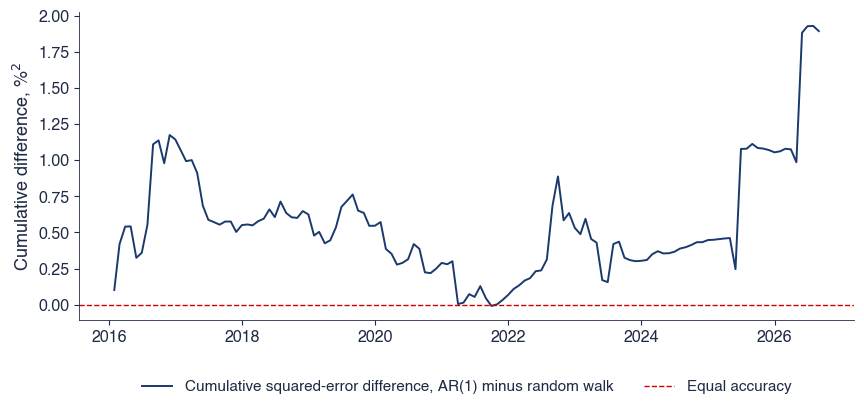

{'P': 128, 'first': '2016-01-31', 'last': '2026-08-31', 'W': 60, 'rmse_rw': 0.5092784095669081, 'rmse_ar': 0.5236018853665395, 'ratio': 1.0281250403130424, 'dm': 1.1970841807311783, 'hln': 1.1923989017716496, 'p_dm': 0.23532804751819753, 'cw': 1.1090989311883697, 'p_cw': 0.13369375296802272, 'rho1': -0.00658583284139899, 'sd_d': 0.15347115572661815, 'dbar': 0.014794435908395366, 'gain_sd': 0.09639880431179557, 'p80_02': 196.22199335872716}


In [18]:
# Solution
r = b1_meese_rogoff(save_it=False)
print(r)

**Interpretation of the result.** The AR(1) does not beat the random walk, and the sample could only have detected a large gain.

## B2 [Proposed]: the term spread and growth

**Context.** FRED real GDP and yields, 1962-2025, four-quarter growth on the spread. Model: B1.

1. Classical, 3-lag and Newey-West standard errors.
2. Why at least MA(3); the residual autocorrelation.
3. Before 1989 and from 1989.
4. Rewrite the team's sentence.

**Report:** a slope, three standard errors and t-statistics, one autocorrelation, two subsample slopes, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: a leakage audit

**Context.** Pure-noise predictors and target, T = 240, last 60 periods for testing, the 5 best of 100 predictors kept.

1. The team's protocol and the honest protocol.
2. Mean out-of-sample R^2 and the share of positive values.
3. The leaking line and the fix.
4. What to require before believing a reported R^2.

**Report:** four numbers, one line of code, one sentence.

In [20]:
# Solution
print(b3_leakage())

{'leaky': 0.05856253673923489, 'honest': -0.13319546676363536, 'leaky_pos': 0.808, 'honest_pos': 0.083, 'leaky_q90': 0.14401182501124352}


**Interpretation of the result.** Selection on the whole sample creates a positive out-of-sample R^2 from noise.

## B4 [Proposed]: a rule search on the BET

**Context.** BET daily log returns, 2001-2012, 20 moving-average rules. Model: B3.

1. The t-statistic of every rule and the naive p-value of the best.
2. The max-t p-value with the stationary bootstrap.
3. Why joint resampling in blocks.
4. What to add before calling it profitable.

**Report:** 20 statistics, two p-values, one critical value, one sentence.

In [ ]:
# Your code here


# Part C: your project and an AI critique

## C1 [Proposed]: the pre-registration of your project

**Context.** Your team's paper and data; the power formula. Model: B1.

1. The seven sections of the template.
2. The verdict rule.
3. The evaluation length for 80% power.
4. How to change the question if the data are too short.

**Report:** one page, one rule, one number, one sentence.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** Seven statements about the project and the defence (slides).

1. For each statement: correct or not; the correct statement and number.

**Report:** seven verdicts with one line each.

In [ ]:
# Your code here
